Total samples: 113

===== SVR - single band (overall CV results) =====
RMSE = 4.1433
R2   = 0.5968
MAE  = 3.0827
Bias = -1.2441

-- Fold 1 --
RMSE = 3.7036, R2 = 0.8036, MAE = 2.8427, Bias = -0.0432

-- Fold 2 --
RMSE = 3.5210, R2 = 0.5341, MAE = 2.8389, Bias = -0.7001

-- Fold 3 --
RMSE = 5.2565, R2 = 0.5407, MAE = 4.3948, Bias = -3.9318

-- Fold 4 --
RMSE = 6.2296, R2 = 0.6373, MAE = 4.1671, Bias = -2.7992

-- Fold 5 --
RMSE = 3.9406, R2 = 0.4179, MAE = 2.6346, Bias = -1.8758

-- Fold 6 --
RMSE = 3.7816, R2 = 0.2045, MAE = 3.2070, Bias = -0.5951

-- Fold 7 --
RMSE = 4.2252, R2 = 0.0601, MAE = 3.3699, Bias = -1.6863

-- Fold 8 --
RMSE = 3.7980, R2 = 0.4192, MAE = 2.9096, Bias = -0.3920

-- Fold 9 --
RMSE = 3.4961, R2 = 0.0386, MAE = 2.4958, Bias = -1.5268

-- Fold 10 --
RMSE = 2.1415, R2 = 0.8721, MAE = 1.8914, Bias = 1.1948

===== K-fold CV metrics (mean ± std) =====
RMSE: 4.0094 ± 1.0352
R2  : 0.4528 ± 0.2715
MAE : 3.0752 ± 0.7146
Bias: -1.2355 ± 1.3838


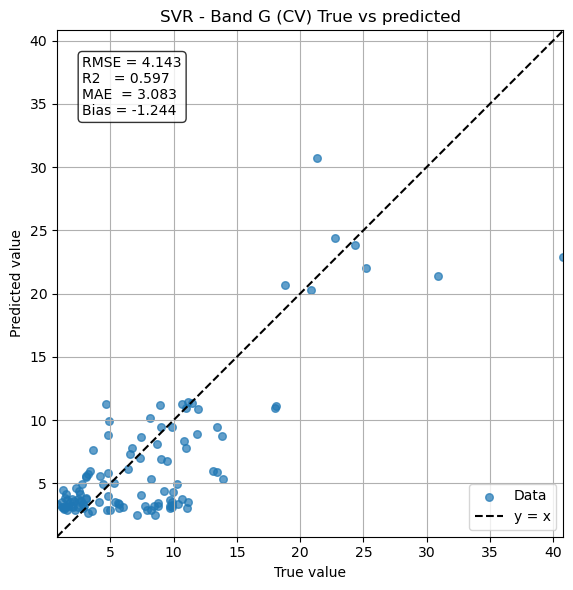

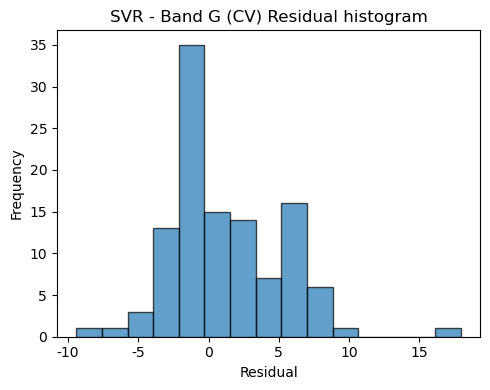

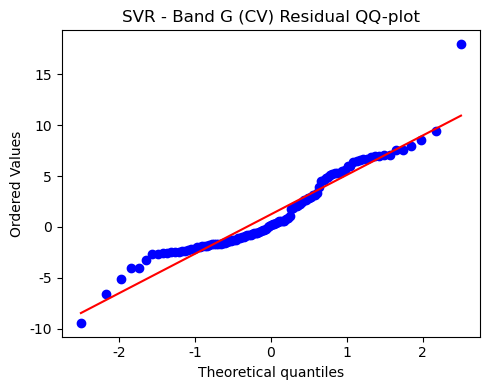

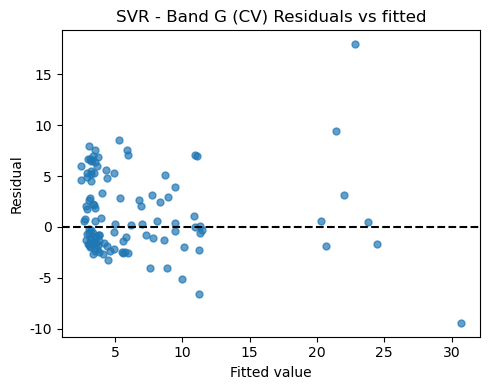


===== Bootstrap 95% confidence intervals (based on CV predictions) =====
RMSE: 4.1433  (95% CI: [3.4031, 4.9915])
R2  : 0.5968  (95% CI: [0.3883, 0.7018])


In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy.stats as stats

from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ====== Basic settings: font & random seed ======
rcParams['axes.unicode_minus'] = False
np.random.seed(0)

# ============================================================
# 1. Read single-band data (here: band B)
#    To switch band later, just change excel_path / usecols
# ============================================================
excel_path = r"C:\Users\lirui\Desktop\FL\G.xlsx"

# File has a header in the first row; we skip it and use columns A (X) and B (y)
res = pd.read_excel(
    excel_path,
    header=None,
    skiprows=1,
    usecols="A:B"
).values

X_all = res[:, 0].reshape(-1, 1)   # shape: (n_samples, 1)
y_all = res[:, 1]                  # shape: (n_samples,)

n_samples = X_all.shape[0]
print(f"Total samples: {n_samples}")

# ============================================================
# 2. Define SVR model and K-fold CV
# ============================================================
# SVR 对特征尺度比较敏感，一般要标准化 => 用 Pipeline(scaler + SVR)
svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(
        kernel='rbf',      # 常用核：'rbf'
        C=100.0,           # 惩罚系数，可调
        epsilon=0.1,       # epsilon-insensitive tube
        gamma='scale'      # 默认 'scale' 通常就可以
    ))
])

# K-fold CV (e.g., 10 folds)
K = 10
cv = KFold(n_splits=K, shuffle=True, random_state=0)

# ============================================================
# 3. Cross-validation: out-of-fold predictions
# ============================================================
y_cv_pred = cross_val_predict(svr_model, X_all, y_all, cv=cv)
resid_cv  = y_all - y_cv_pred

# ============================================================
# 4. Metrics: overall and fold-wise
# ============================================================

def regression_metrics(y_true, y_pred):
    """Return RMSE, R2, MAE, Bias."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)   # positive => overestimation
    return rmse, r2, mae, bias

# ---- 4.1 Overall metrics (based on all out-of-fold predictions) ----
rmse_all, r2_all, mae_all, bias_all = regression_metrics(y_all, y_cv_pred)

print("\n===== SVR - single band (overall CV results) =====")
print(f"RMSE = {rmse_all:.4f}")
print(f"R2   = {r2_all:.4f}")
print(f"MAE  = {mae_all:.4f}")
print(f"Bias = {bias_all:.4f}")

# ---- 4.2 Fold-wise metrics: for tables (mean ± std) ----
rmse_folds = []
r2_folds   = []
mae_folds  = []
bias_folds = []

fold_id = 1
for train_idx, test_idx in cv.split(X_all):
    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = y_all[train_idx], y_all[test_idx]

    # For each fold, create an independent SVR model with the same structure
    svr_model_fold = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(
            kernel='rbf',
            C=100.0,
            epsilon=0.1,
            gamma='scale'
        ))
    ])

    svr_model_fold.fit(X_tr, y_tr)
    y_te_pred = svr_model_fold.predict(X_te)

    rmse, r2, mae, bias = regression_metrics(y_te, y_te_pred)
    rmse_folds.append(rmse)
    r2_folds.append(r2)
    mae_folds.append(mae)
    bias_folds.append(bias)

    print(f"\n-- Fold {fold_id} --")
    print(f"RMSE = {rmse:.4f}, R2 = {r2:.4f}, MAE = {mae:.4f}, Bias = {bias:.4f}")
    fold_id += 1

print("\n===== K-fold CV metrics (mean ± std) =====")
print(f"RMSE: {np.mean(rmse_folds):.4f} ± {np.std(rmse_folds):.4f}")
print(f"R2  : {np.mean(r2_folds ):.4f} ± {np.std(r2_folds ):.4f}")
print(f"MAE : {np.mean(mae_folds):.4f} ± {np.std(mae_folds):.4f}")
print(f"Bias: {np.mean(bias_folds):.4f} ± {np.std(bias_folds):.4f}")

# ============================================================
# 5. Figure 7-style diagnostics (based on CV predictions)
#    5.1: True vs Predicted scatter, with 1:1 line & in-panel metrics
#    5.2: Residual histogram
#    5.3: Residual QQ plot
#    5.4: Residuals vs Fitted
#    => 4 separate figures, each saved as PNG
# ============================================================

def scatter_true_vs_pred(y_true, y_pred, title_prefix="", save_prefix=None):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Scatter points with label
    ax.scatter(y_true, y_pred, s=30, alpha=0.7, label='Data')

    # 1:1 reference line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], '--k', label='y = x')

    # Same axis limits & aspect ratio = 1
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect('equal', adjustable='box')

    # Metrics text (Top-Left corner, English, R2 without superscript)
    rmse, r2, mae, bias = regression_metrics(y_true, y_pred)
    text_str = (
        f"RMSE = {rmse:.3f}\n"
        f"R2   = {r2:.3f}\n"
        f"MAE  = {mae:.3f}\n"
        f"Bias = {bias:.3f}"
    )
    ax.text(
        0.05, 0.95, text_str,
        transform=ax.transAxes,
        va='top', ha='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    ax.set_xlabel('True value')
    ax.set_ylabel('Predicted value')
    ax.set_title(f'{title_prefix}True vs predicted')
    ax.grid(True)

    # Legend at lower right to avoid overlap with metrics text
    ax.legend(loc='lower right')

    plt.tight_layout()

    # Save figure if required
    if save_prefix is not None:
        fig.savefig(f"{save_prefix}_scatter.png", dpi=300, bbox_inches="tight")

    plt.show()

def residual_diagnostics(y_true, y_pred, title_prefix="", save_prefix=None):
    residuals = y_true - y_pred
    fitted    = y_pred

    # ===== (1) Residual histogram =====
    fig1, ax1 = plt.subplots(figsize=(5, 4))
    ax1.hist(residuals, bins=15, edgecolor='k', alpha=0.7)
    ax1.set_xlabel('Residual')
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'{title_prefix}Residual histogram')
    plt.tight_layout()
    if save_prefix is not None:
        fig1.savefig(f"{save_prefix}_residual_hist.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ===== (2) QQ plot =====
    fig2, ax2 = plt.subplots(figsize=(5, 4))
    stats.probplot(residuals, dist='norm', plot=ax2)
    ax2.set_title(f'{title_prefix}Residual QQ-plot')
    plt.tight_layout()
    if save_prefix is not None:
        fig2.savefig(f"{save_prefix}_residual_qq.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ===== (3) Residuals vs fitted =====
    fig3, ax3 = plt.subplots(figsize=(5, 4))
    ax3.scatter(fitted, residuals, s=25, alpha=0.7)
    ax3.axhline(0, color='k', linestyle='--')
    ax3.set_xlabel('Fitted value')
    ax3.set_ylabel('Residual')
    ax3.set_title(f'{title_prefix}Residuals vs fitted')
    plt.tight_layout()
    if save_prefix is not None:
        fig3.savefig(f"{save_prefix}_residual_vs_fitted.png", dpi=300, bbox_inches="tight")
    plt.show()

# ---- 5.x: call diagnostics & save 4 figures ----
# You can change save_prefix or use an absolute path
# e.g., r"C:\Users\lirui\Desktop\FL\SVR_BandB_CV"
save_prefix = r"SVR_BandG_CV"

scatter_true_vs_pred(
    y_all, y_cv_pred,
    title_prefix="SVR - Band G (CV) ",
    save_prefix=save_prefix
)

residual_diagnostics(
    y_all, y_cv_pred,
    title_prefix="SVR - Band G (CV) ",
    save_prefix=save_prefix
)

# ============================================================
# 6. Bootstrap confidence intervals (RMSE and R2)
# ============================================================

def bootstrap_ci(y_true, y_pred, metric_func, n_boot=1000, alpha=0.05):
    """
    y_true, y_pred: full-sample vectors
    metric_func: function (y_true_boot, y_pred_boot) -> scalar metric
    return: (lower, upper) CI
    """
    rng = np.random.default_rng(0)
    n  = len(y_true)
    vals = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)  # resample with replacement
        yt_boot = y_true[idx]
        yp_boot = y_pred[idx]
        vals.append(metric_func(yt_boot, yp_boot))

    vals = np.array(vals)
    lower = np.quantile(vals, alpha/2)
    upper = np.quantile(vals, 1 - alpha/2)
    return lower, upper

def rmse_fn(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def r2_fn(y_true, y_pred):
    return r2_score(y_true, y_pred)

rmse_l, rmse_u = bootstrap_ci(y_all, y_cv_pred, rmse_fn, n_boot=1000, alpha=0.05)
r2_l,   r2_u   = bootstrap_ci(y_all, y_cv_pred, r2_fn,   n_boot=1000, alpha=0.05)

print("\n===== Bootstrap 95% confidence intervals (based on CV predictions) =====")
print(f"RMSE: {rmse_all:.4f}  (95% CI: [{rmse_l:.4f}, {rmse_u:.4f}])")
print(f"R2  : {r2_all:.4f}  (95% CI: [{r2_l:.4f}, {r2_u:.4f}])")


Total samples: 113

===== Grid search over SVR hyperparameters (RBF kernel) =====
[TRY] C=1.0, eps=0.01, gamma=scale => mean R2 = 0.4657
[TRY] C=1.0, eps=0.01, gamma=auto => mean R2 = 0.4657
[TRY] C=1.0, eps=0.01, gamma=0.01 => mean R2 = 0.1425
[TRY] C=1.0, eps=0.01, gamma=0.1 => mean R2 = 0.4527
[TRY] C=1.0, eps=0.01, gamma=1.0 => mean R2 = 0.4657
[TRY] C=1.0, eps=0.05, gamma=scale => mean R2 = 0.4644
[TRY] C=1.0, eps=0.05, gamma=auto => mean R2 = 0.4644
[TRY] C=1.0, eps=0.05, gamma=0.01 => mean R2 = 0.1418
[TRY] C=1.0, eps=0.05, gamma=0.1 => mean R2 = 0.4535
[TRY] C=1.0, eps=0.05, gamma=1.0 => mean R2 = 0.4644
[TRY] C=1.0, eps=0.1, gamma=scale => mean R2 = 0.4626
[TRY] C=1.0, eps=0.1, gamma=auto => mean R2 = 0.4626
[TRY] C=1.0, eps=0.1, gamma=0.01 => mean R2 = 0.1408
[TRY] C=1.0, eps=0.1, gamma=0.1 => mean R2 = 0.4539
[TRY] C=1.0, eps=0.1, gamma=1.0 => mean R2 = 0.4626
[TRY] C=1.0, eps=0.2, gamma=scale => mean R2 = 0.4651
[TRY] C=1.0, eps=0.2, gamma=auto => mean R2 = 0.4651
[TRY] C=1

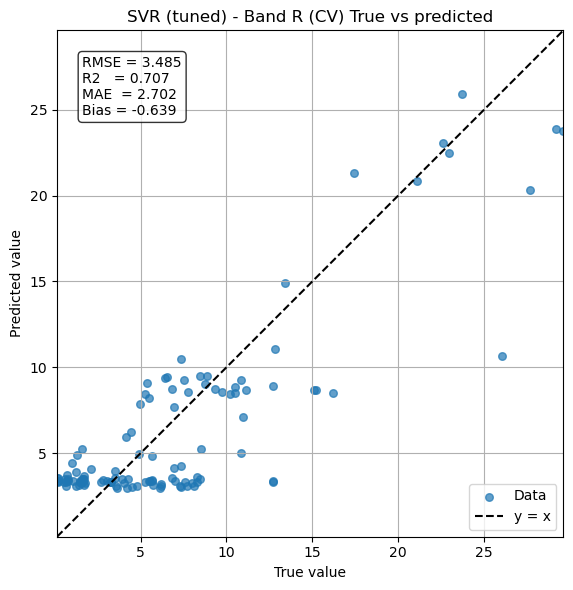

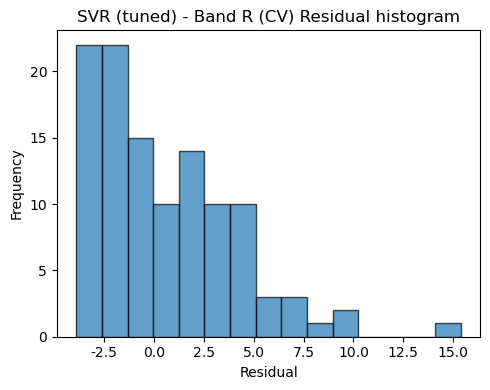

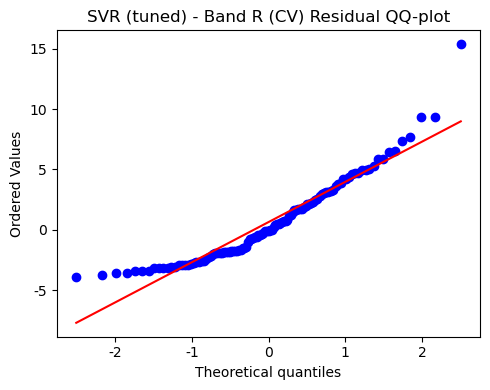

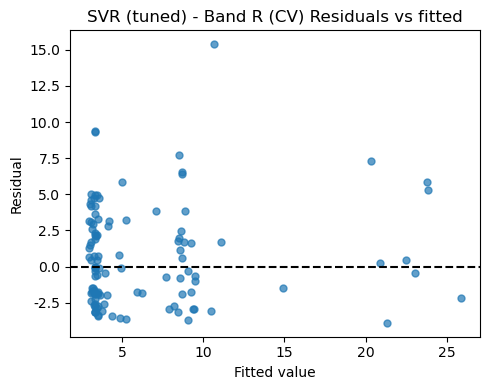


===== Bootstrap 95% confidence intervals (based on CV predictions) =====
RMSE: 3.4853  (95% CI: [2.8434, 4.1775])
R2  : 0.7074  (95% CI: [0.5327, 0.8034])


In [7]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy.stats as stats

from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ====== Basic settings: font & random seed ======
rcParams['axes.unicode_minus'] = False
np.random.seed(0)

# ============================================================
# 1. Read single-band data (here: band G)
#    To switch band later, just change excel_path / usecols
# ============================================================
excel_path = r"C:\Users\lirui\Desktop\FL\R.xlsx"

# File has a header in the first row; we skip it and use columns A (X) and B (y)
res = pd.read_excel(
    excel_path,
    header=None,
    skiprows=1,
    usecols="A:B"
).values

X_all = res[:, 0].reshape(-1, 1)   # shape: (n_samples, 1)
y_all = res[:, 1]                  # shape: (n_samples,)

n_samples = X_all.shape[0]
print(f"Total samples: {n_samples}")

# ============================================================
# 2. Define K-fold CV
# ============================================================
K = 10
cv = KFold(n_splits=K, shuffle=True, random_state=0)

# ============================================================
# 3. Small grid search for SVR hyperparameters (to improve R2)
# ============================================================
param_grid = {
    "C":       [1.0, 10.0, 100.0, 1000.0],
    "epsilon": [0.01, 0.05, 0.1, 0.2],
    "gamma":   ["scale", "auto", 0.01, 0.1, 1.0],  # for RBF kernel
}

best_mean_r2 = -np.inf
best_params  = None

print("\n===== Grid search over SVR hyperparameters (RBF kernel) =====")
for C in param_grid["C"]:
    for eps in param_grid["epsilon"]:
        for gamma in param_grid["gamma"]:
            svr_tmp = Pipeline([
                ('scaler', StandardScaler()),
                ('svr', SVR(
                    kernel='rbf',
                    C=C,
                    epsilon=eps,
                    gamma=gamma
                ))
            ])
            r2_scores = cross_val_score(
                svr_tmp, X_all, y_all,
                cv=cv,
                scoring="r2"
            )
            mean_r2 = r2_scores.mean()
            print(f"[TRY] C={C}, eps={eps}, gamma={gamma} => mean R2 = {mean_r2:.4f}")

            if mean_r2 > best_mean_r2:
                best_mean_r2 = mean_r2
                best_params  = {
                    "C": C,
                    "epsilon": eps,
                    "gamma": gamma
                }

print("\n===== Best SVR params by CV (R2) =====")
print(best_params)
print(f"Best mean R2 = {best_mean_r2:.4f}")

# ============================================================
# 4. Build final SVR model with best_params and get CV predictions
# ============================================================
svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(
        kernel='rbf',
        C=best_params["C"],
        epsilon=best_params["epsilon"],
        gamma=best_params["gamma"]
    ))
])

# Cross-validated predictions (out-of-fold)
y_cv_pred = cross_val_predict(svr_model, X_all, y_all, cv=cv)
resid_cv  = y_all - y_cv_pred

# ============================================================
# 5. Metrics: overall and fold-wise
# ============================================================

def regression_metrics(y_true, y_pred):
    """Return RMSE, R2, MAE, Bias."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)   # positive => overestimation
    return rmse, r2, mae, bias

# ---- 5.1 Overall metrics (based on all out-of-fold predictions) ----
rmse_all, r2_all, mae_all, bias_all = regression_metrics(y_all, y_cv_pred)

print("\n===== SVR (tuned) - single band G (overall CV results) =====")
print(f"RMSE = {rmse_all:.4f}")
print(f"R2   = {r2_all:.4f}")
print(f"MAE  = {mae_all:.4f}")
print(f"Bias = {bias_all:.4f}")

# ---- 5.2 Fold-wise metrics: for tables (mean ± std) ----
rmse_folds = []
r2_folds   = []
mae_folds  = []
bias_folds = []

fold_id = 1
for train_idx, test_idx in cv.split(X_all):
    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = y_all[train_idx], y_all[test_idx]

    svr_model_fold = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(
            kernel='rbf',
            C=best_params["C"],
            epsilon=best_params["epsilon"],
            gamma=best_params["gamma"]
        ))
    ])

    svr_model_fold.fit(X_tr, y_tr)
    y_te_pred = svr_model_fold.predict(X_te)

    rmse, r2, mae, bias = regression_metrics(y_te, y_te_pred)
    rmse_folds.append(rmse)
    r2_folds.append(r2)
    mae_folds.append(mae)
    bias_folds.append(bias)

    print(f"\n-- Fold {fold_id} --")
    print(f"RMSE = {rmse:.4f}, R2 = {r2:.4f}, MAE = {mae:.4f}, Bias = {bias:.4f}")
    fold_id += 1

print("\n===== K-fold CV metrics (mean ± std) =====")
print(f"RMSE: {np.mean(rmse_folds):.4f} ± {np.std(rmse_folds):.4f}")
print(f"R2  : {np.mean(r2_folds ):.4f} ± {np.std(r2_folds ):.4f}")
print(f"MAE : {np.mean(mae_folds):.4f} ± {np.std(mae_folds):.4f}")
print(f"Bias: {np.mean(bias_folds):.4f} ± {np.std(bias_folds):.4f}")

# ============================================================
# 6. Figure 7-style diagnostics (based on CV predictions)
# ============================================================

def scatter_true_vs_pred(y_true, y_pred, title_prefix="", save_prefix=None):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Scatter points with label
    ax.scatter(y_true, y_pred, s=30, alpha=0.7, label='Data')

    # 1:1 reference line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], '--k', label='y = x')

    # Same axis limits & aspect ratio = 1
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect('equal', adjustable='box')

    # Metrics text (Top-Left corner, English, R2 without superscript)
    rmse, r2, mae, bias = regression_metrics(y_true, y_pred)
    text_str = (
        f"RMSE = {rmse:.3f}\n"
        f"R2   = {r2:.3f}\n"
        f"MAE  = {mae:.3f}\n"
        f"Bias = {bias:.3f}"
    )
    ax.text(
        0.05, 0.95, text_str,
        transform=ax.transAxes,
        va='top', ha='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    ax.set_xlabel('True value')
    ax.set_ylabel('Predicted value')
    ax.set_title(f'{title_prefix}True vs predicted')
    ax.grid(True)

    # Legend at lower right to avoid overlap with metrics text
    ax.legend(loc='lower right')

    plt.tight_layout()

    # Save figure if required
    if save_prefix is not None:
        fig.savefig(f"{save_prefix}_scatter.png", dpi=300, bbox_inches="tight")

    plt.show()

def residual_diagnostics(y_true, y_pred, title_prefix="", save_prefix=None):
    residuals = y_true - y_pred
    fitted    = y_pred

    # ===== (1) Residual histogram =====
    fig1, ax1 = plt.subplots(figsize=(5, 4))
    ax1.hist(residuals, bins=15, edgecolor='k', alpha=0.7)
    ax1.set_xlabel('Residual')
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'{title_prefix}Residual histogram')
    plt.tight_layout()
    if save_prefix is not None:
        fig1.savefig(f"{save_prefix}_residual_hist.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ===== (2) QQ plot =====
    fig2, ax2 = plt.subplots(figsize=(5, 4))
    stats.probplot(residuals, dist='norm', plot=ax2)
    ax2.set_title(f'{title_prefix}Residual QQ-plot')
    plt.tight_layout()
    if save_prefix is not None:
        fig2.savefig(f"{save_prefix}_residual_qq.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ===== (3) Residuals vs fitted =====
    fig3, ax3 = plt.subplots(figsize=(5, 4))
    ax3.scatter(fitted, residuals, s=25, alpha=0.7)
    ax3.axhline(0, color='k', linestyle='--')
    ax3.set_xlabel('Fitted value')
    ax3.set_ylabel('Residual')
    ax3.set_title(f'{title_prefix}Residuals vs fitted')
    plt.tight_layout()
    if save_prefix is not None:
        fig3.savefig(f"{save_prefix}_residual_vs_fitted.png", dpi=300, bbox_inches="tight")
    plt.show()

# ---- 6.x: call diagnostics & save 4 figures ----
# You can change save_prefix or use an absolute path
# e.g., r"C:\Users\lirui\Desktop\FL\SVR_BandG_CV"
save_prefix = r"SVR_BandR_CV"

scatter_true_vs_pred(
    y_all, y_cv_pred,
    title_prefix="SVR (tuned) - Band R (CV) ",
    save_prefix=save_prefix
)

residual_diagnostics(
    y_all, y_cv_pred,
    title_prefix="SVR (tuned) - Band R (CV) ",
    save_prefix=save_prefix
)

# ============================================================
# 7. Bootstrap confidence intervals (RMSE and R2)
# ============================================================

def bootstrap_ci(y_true, y_pred, metric_func, n_boot=1000, alpha=0.05):
    """
    y_true, y_pred: full-sample vectors
    metric_func: function (y_true_boot, y_pred_boot) -> scalar metric
    return: (lower, upper) CI
    """
    rng = np.random.default_rng(0)
    n  = len(y_true)
    vals = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)  # resample with replacement
        yt_boot = y_true[idx]
        yp_boot = y_pred[idx]
        vals.append(metric_func(yt_boot, yp_boot))

    vals = np.array(vals)
    lower = np.quantile(vals, alpha/2)
    upper = np.quantile(vals, 1 - alpha/2)
    return lower, upper

def rmse_fn(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def r2_fn(y_true, y_pred):
    return r2_score(y_true, y_pred)

rmse_l, rmse_u = bootstrap_ci(y_all, y_cv_pred, rmse_fn, n_boot=1000, alpha=0.05)
r2_l,   r2_u   = bootstrap_ci(y_all, y_cv_pred, r2_fn,   n_boot=1000, alpha=0.05)

print("\n===== Bootstrap 95% confidence intervals (based on CV predictions) =====")
print(f"RMSE: {rmse_all:.4f}  (95% CI: [{rmse_l:.4f}, {rmse_u:.4f}])")
print(f"R2  : {r2_all:.4f}  (95% CI: [{r2_l:.4f}, {r2_u:.4f}])")
